Trial 2 Complete [00h 02m 08s]
val_loss: 0.11395809054374695

Best val_loss So Far: 0.015090093947947025
Total elapsed time: 00h 04m 28s
Optimal Filters: 32
Training final model...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 131ms/step - loss: 0.1326 - val_loss: 0.1141
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 128ms/step - loss: 0.1121 - val_loss: 0.1140
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 128ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 87s 138ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 65s 139ms/step - loss: 0.1120 - val_loss: 0.1140
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


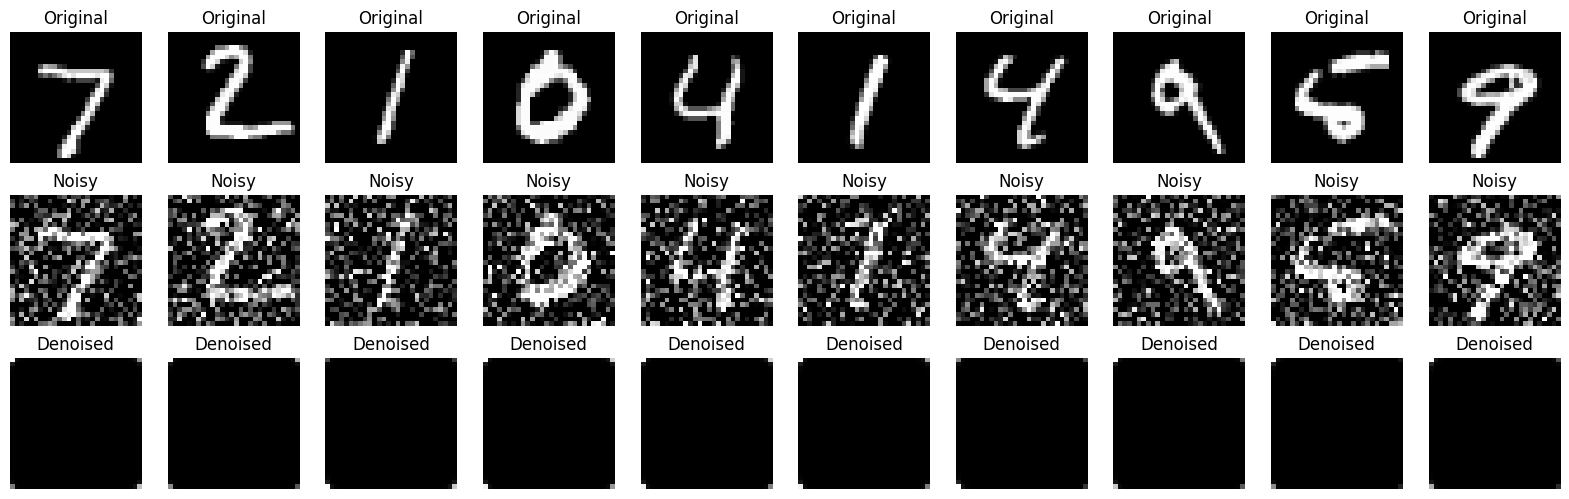

In [1]:
# Install the missing library
!pip install -q -U keras-tuner

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import keras_tuner as kt

# ==========================================
# 1. Load and Prepare the MNIST Dataset
# ==========================================
# Fetching handwritten digits (0-9)
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape to (28, 28, 1) for Convolutional layers
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Add synthetic Gaussian noise
# We increase the noise_factor to make the "denoising" task visible
noise_factor = 0.4
x_train_noisy = x_train + noise_factor * tf.random.normal(shape=x_train.shape)
x_test_noisy = x_test + noise_factor * tf.random.normal(shape=x_test.shape)

# Clip values to stay within valid image bounds [0, 1]
x_train_noisy = tf.clip_by_value(x_train_noisy, clip_value_min=0., clip_value_max=1.)
x_test_noisy = tf.clip_by_value(x_test_noisy, clip_value_min=0., clip_value_max=1.)

# ==========================================
# 2. Define Model Builder for Hyperparameter Tuning
# ==========================================
def build_model(hp):
    model = models.Sequential()

    # Tune the number of filters
    hp_filters = hp.Int('filters', min_value=16, max_value=48, step=16)

    # Encoder: Shrinks the noisy image to capture "shapes" not "noise"
    model.add(layers.Input(shape=(28, 28, 1)))
    model.add(layers.Conv2D(hp_filters, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2), padding='same'))
    model.add(layers.Conv2D(hp_filters // 2, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2), padding='same'))

    # Decoder: Reconstructs the clean image from the compressed patterns
    model.add(layers.Conv2D(hp_filters // 2, (3, 3), activation='relu', padding='same'))
    model.add(layers.UpSampling2D((2, 2)))
    model.add(layers.Conv2D(hp_filters, (3, 3), activation='relu', padding='same'))
    model.add(layers.UpSampling2D((2, 2)))
    model.add(layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same'))

    # Tune the learning rate
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
                  loss='mse')
    return model

# ==========================================
# 3. Execute Hyperparameter Tuning
# ==========================================
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=2,
    directory='mnist_denoising_tuning',
    project_name='digit_denoiser'
)

print("Starting Tuning...")
tuner.search(x_train_noisy, x_train, epochs=2, validation_data=(x_test_noisy, x_test))

# Get best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Optimal Filters: {best_hps.get('filters')}")

# ==========================================
# 4. Train the Final Model
# ==========================================
print("Training final model...")
model = tuner.hypermodel.build(best_hps)
model.fit(x_train_noisy, x_train, epochs=5, batch_size=128, validation_data=(x_test_noisy, x_test))

# ==========================================
# 5. Visualizing the Output
# ==========================================
decoded_imgs = model.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Display Noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].numpy().reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Display Reconstruction (Denoised)
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')
plt.show()

Training the final model...
Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 129ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 134ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 133ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 63s 135ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 133ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 131ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 129ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 136ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 64s 137ms/step - loss: 0.1120 - val_loss: 0.1140
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 62s 133ms/step - loss: 0.1120 - val_loss: 0.1140


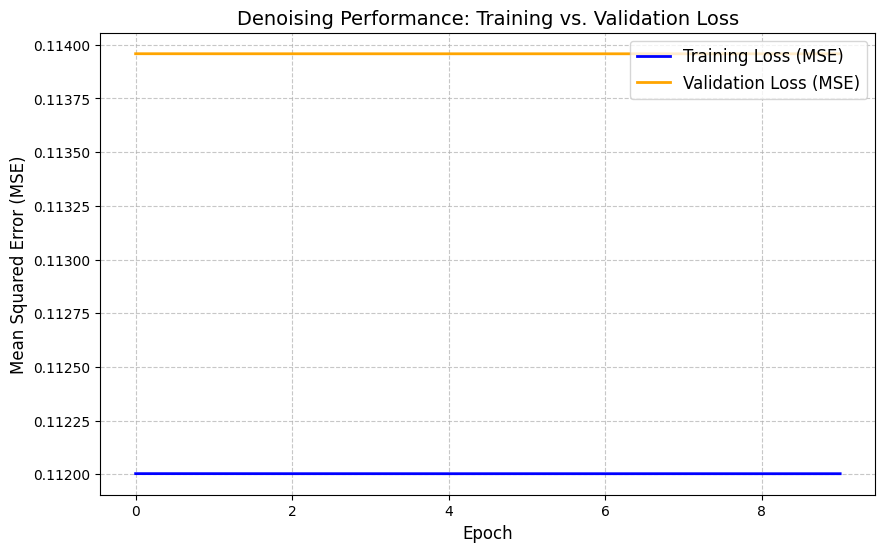

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


/tmp/ipykernel_3091/86394984.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ssim_noisy.numpy(), ssim_denoised.numpy()],


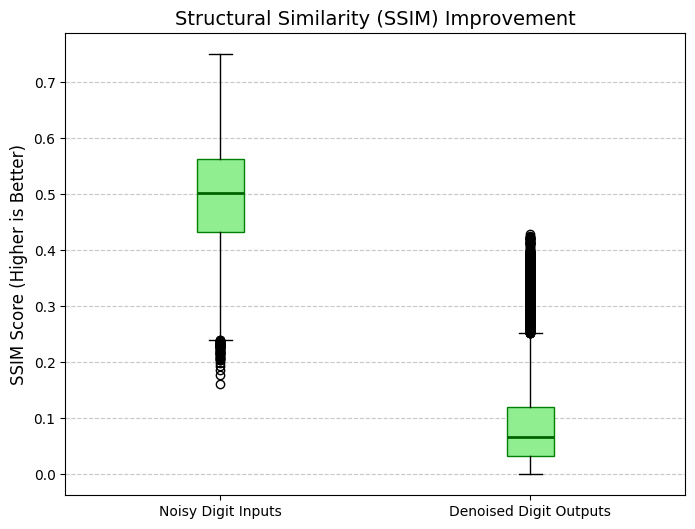

Average SSIM (Noisy Digit): 0.4912
Average SSIM (Denoised Digit): 0.0956


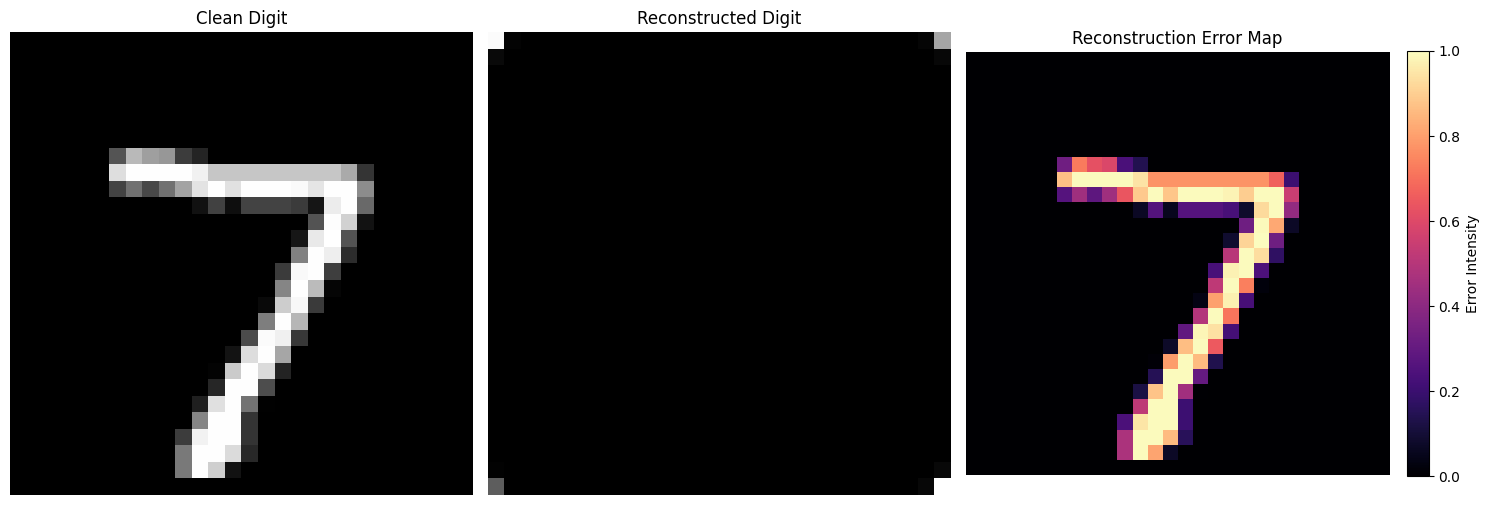

In [4]:
# ==========================================
# 1. Final Training (Run this to define 'history')
# ==========================================
print("Training the final model...")
# Ensure you use 'history =' at the start of this line
history = model.fit(
    x_train_noisy, x_train,
    epochs=10,  # Increased epochs for better results
    batch_size=128,
    validation_data=(x_test_noisy, x_test),
    verbose=1
)

# ==========================================
# 2. Performance Analysis Plots
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Chart 1: Training vs. Validation Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange', linewidth=2)
plt.title('Denoising Performance: Training vs. Validation Loss', fontsize=14)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Chart 2: SSIM (Structural Similarity Index) Boxplot
# SSIM measures how much of the digit's structure was saved.
decoded_imgs = model.predict(x_test_noisy)
ssim_noisy = tf.image.ssim(x_test, x_test_noisy, max_val=1.0)
ssim_denoised = tf.image.ssim(x_test, decoded_imgs, max_val=1.0)

plt.figure(figsize=(8, 6))
plt.boxplot([ssim_noisy.numpy(), ssim_denoised.numpy()],
            labels=['Noisy Digit Inputs', 'Denoised Digit Outputs'],
            patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='green'),
            medianprops=dict(color='darkgreen', linewidth=2))
plt.title('Structural Similarity (SSIM) Improvement', fontsize=14)
plt.ylabel('SSIM Score (Higher is Better)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Average SSIM (Noisy Digit): {np.mean(ssim_noisy):.4f}")
print(f"Average SSIM (Denoised Digit): {np.mean(ssim_denoised):.4f}")

# Chart 3: Pixel-wise Absolute Error Heatmap
index_to_visualize = 0
orig_img = np.squeeze(x_test[index_to_visualize])
denoised_img = np.squeeze(decoded_imgs[index_to_visualize])
error_map = np.abs(orig_img - denoised_img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(orig_img, cmap='gray')
axes[0].set_title(f'Clean Digit', fontsize=12)
axes[0].axis('off')

axes[1].imshow(denoised_img, cmap='gray')
axes[1].set_title('Reconstructed Digit', fontsize=12)
axes[1].axis('off')

im = axes[2].imshow(error_map, cmap='magma')
axes[2].set_title('Reconstruction Error Map', fontsize=12)
axes[2].axis('off')
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label='Error Intensity')

plt.tight_layout()
plt.show()